In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
visualization_df = pd.read_csv('../../data/processed/final_EDA_df.csv')
visualization_df.head()

,고객ID,패션뉴스구독여부,멤버십상태,뉴스레터수신빈도,연령,구매일,가격,상품그룹,연령대,거래날짜,이전구매일,구매간격(일),API ratio,전체고객이탈여부,신규고객이탈
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.044051,Garment Upper body,40대,2018-12-27,0,0.0,68.666667,0,0
1,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.035576,Garment Upper body,40대,2018-12-27,2018-12-27 00:00:00,0.0,68.666667,0,0
2,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.030492,Garment Upper body,40대,2018-12-27,2018-12-27 00:00:00,0.0,68.666667,0,0
3,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-02,0.010153,Garment Full body,40대,2019-05-02,2018-12-27 00:00:00,126.0,68.666667,0,0
4,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-25,0.050831,Garment Upper body,40대,2019-05-25,2019-05-02 00:00:00,23.0,68.666667,0,0


In [3]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:

df = visualization_df.copy()
df.head()


,고객ID,패션뉴스구독여부,멤버십상태,뉴스레터수신빈도,연령,구매일,가격,상품그룹,연령대,거래날짜,이전구매일,구매간격(일),API ratio,전체고객이탈여부,신규고객이탈
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.044051,Garment Upper body,40대,2018-12-27,0,0.0,68.666667,0,0
1,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.035576,Garment Upper body,40대,2018-12-27,2018-12-27 00:00:00,0.0,68.666667,0,0
2,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.030492,Garment Upper body,40대,2018-12-27,2018-12-27 00:00:00,0.0,68.666667,0,0
3,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-02,0.010153,Garment Full body,40대,2019-05-02,2018-12-27 00:00:00,126.0,68.666667,0,0
4,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-25,0.050831,Garment Upper body,40대,2019-05-25,2019-05-02 00:00:00,23.0,68.666667,0,0


# 전체 고객 이탈 여부 + 신규 고객 이탈 여부

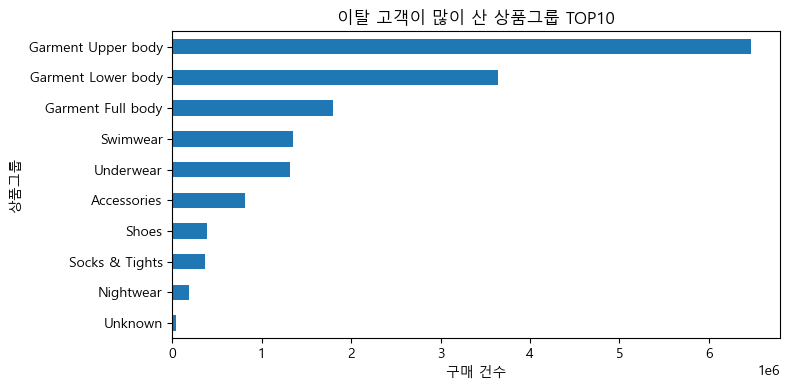

In [5]:
# # 이탈 고객이 많이 산 거
all_churn_df = df[df['전체고객이탈여부'] == 1]

all_top_10 = all_churn_df['상품그룹'].value_counts().head(10) # value_counts()는 각 고유값의 빈도수를 계산하는 함수

ax = all_top_10.sort_values().plot(kind='barh', figsize=(8,4)) # sort_values()는 시리즈나 데이터프레임의 값을 정렬하는 함수
ax.set_title('이탈 고객이 많이 산 상품그룹 TOP10')
ax.set_xlabel('구매 건수')
plt.tight_layout()  # tight_layout()는 그래프 요소들이 겹치지 않도록 자동으로 조정하는 함수
plt.show()

In [6]:
# # 고객별로 어떤 상품그룹을 가장 많이 샀는지(대표 상품그룹)
main_prod = df.groupby('고객ID')['상품그룹'].agg(lambda x: x.value_counts().idxmax())
# agg는 그룹별로 집계 함수를 적용하는 메서드입니다. 
# 여기서는 lambda 함수를 사용하여 각 고객ID 그룹에서 가장 많이 구매한 상품그룹을 찾습니다. 
# value_counts()는 각 고유값의 빈도수를 계산하는 함수이고, idxmax()는 가장 큰 값을 가진 인덱스를 반환하는 함수입니다. 
# 따라서 이 코드는 각 고객ID에 대해 가장 많이 구매한 상품그룹을 대표 상품그룹으로 선택합니다.

customer_df = df.drop_duplicates('고객ID')
main_prod = main_prod.reset_index()
main_prod.columns = ['고객ID', '상품그룹']

# 고객 정보(이탈여부)와 합치기
cust_prod = customer_df[['고객ID','전체고객이탈여부','신규고객이탈']].merge(main_prod, on='고객ID', how='left')

cust_prod.head()

,고객ID,전체고객이탈여부,신규고객이탈,상품그룹
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0,0,Garment Upper body
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,1,0,Swimwear
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0,0,Garment Upper body
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,1,1,Underwear
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,0,0,Garment Upper body


---

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def make_gradient_colors(s, cmap_name='Reds', min_level=0.35, max_level=0.95):
    vals = s.values.astype(float)
    vmin, vmax = vals.min(), vals.max()

    cmap = plt.get_cmap(cmap_name)

    # 값이 전부 같으면 중간 진하기로 통일
    if vmin == vmax:
        return [cmap((min_level + max_level) / 2)] * len(s)

    # 0~1 정규화
    norm = (vals - vmin) / (vmax - vmin)

    # ✅ 너무 연한 구간을 피해서 (min_level~max_level)만 사용
    norm = min_level + (max_level - min_level) * norm

    colors = [cmap(x) for x in norm]

    # (혹시라도 투명도 걱정되면 alpha=1로 고정)
    colors = [(*c[:3], 1.0) for c in colors]

    return colors

- 공통으로 높으면 ->신규든 기존이든 이탈률이 많이 나오는 상품 -> Interior textile은 전체/신규 모두 이탈률이 매우 높게 나타났음
- cosmetic, Underwear/nightwear 같은 경우는 신규 고객은 생각보다 이탈이 덜한데, 시간이 지나면서 이탈이 많이 생기는 품목을 확인 할 수 있음 -> 시간이 지나면서 재구매로 이어지지 못해 이탈이 됐을 가능성을 보여주는 것으로 해석 할 수 있음


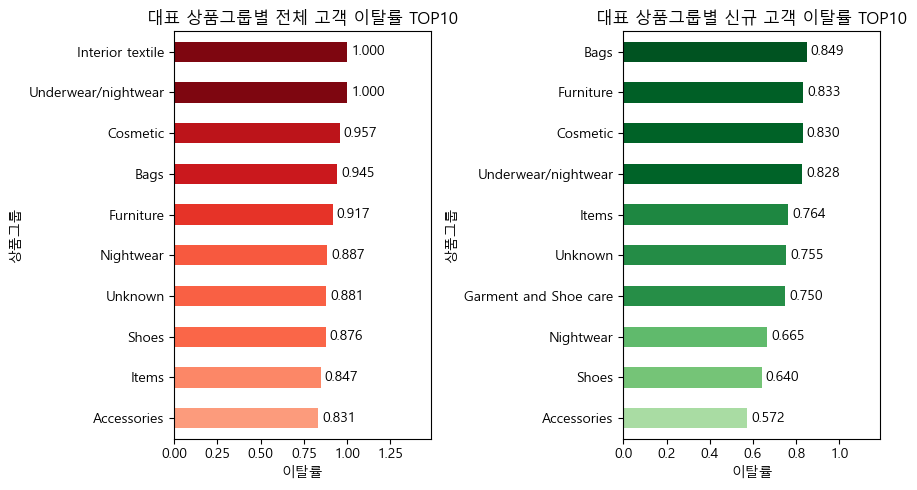

In [8]:
# 대표 상품 그룹별 전체 이탈 여부
# 이걸로 해야징

rate_table = cust_prod.groupby('상품그룹')['전체고객이탈여부'].mean().sort_values(ascending=False)
new_table = cust_prod.groupby('상품그룹')['신규고객이탈'].mean().sort_values(ascending=False)

rate_table = rate_table.iloc[1:]
new_table  = new_table.iloc[1:]

all_top15 = rate_table.head(10)
new_top15 = new_table.head(10)

s1 = all_top15.sort_values()
s2 = new_top15.sort_values()

colors1 = make_gradient_colors(s1, 'Reds')
colors2 = make_gradient_colors(s2, 'Greens')

plt.subplot(1, 2, 1)
ax = all_top15.sort_values().plot(kind='barh', figsize=(9,5), color= colors1)
ax.set_title('대표 상품그룹별 전체 고객 이탈률 TOP10')
ax.set_xlabel('이탈률')
ax.bar_label(ax.containers[0],fmt='%.3f',padding=3)
ax.set_xlim(0, s2.max() * 1.75)
plt.tight_layout() # tight_layout()는 그래프 요소들이 겹치지 않도록 자동으로 조정하는 함수입니다.

# 그래프 색상 설정

plt.subplot(1, 2, 2)
ax = new_top15.sort_values().plot(kind='barh', figsize=(9,5),color= colors2)
ax.set_title("대표 상품그룹별 신규 고객 이탈률 TOP10")
ax.set_xlabel('이탈률')
ax.bar_label(ax.containers[0],fmt='%.3f',padding=3)
ax.set_xlim(0, s2.max() * 1.4)

plt.tight_layout()

plt.show()

---

- 0 : 이탈 x
- 1 : 이탈 o

- 0 인 경우는 어느 정도 구매 간격이 좁은 것을 확인 할 수 있음 -> 구매 간격이 어느 정도 일정.
- 1 인 경우는 구매 간격이 큰 것을 확인 할 수 있음 -> 평균 구매 간격이 0으로 나오는 것으로 봤을 때 신규고객 이탈로 볼 수 있을 듯. 즉, 처음에사고 그 다음에는 사지 않았다는 것을 확인 할 수 있는 그래프로 박스플롯이라고 보면 될 듯. 또는 1회 구매를 했거나 구매 간격이 불규칙함으로 보면 될 듯

C:\Users\USER\AppData\Local\Temp\ipykernel_9016\1244392278.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([keep, churn], labels=['유지(0)','이탈(1)'], showfliers=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_9016\1244392278.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([keep_new, churn_new], labels=['유지(0)','이탈(1)'], showfliers=False)


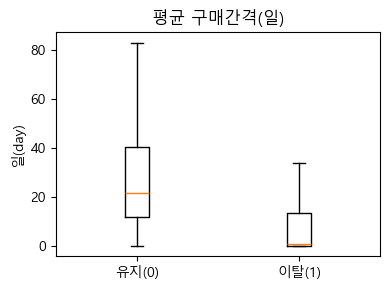

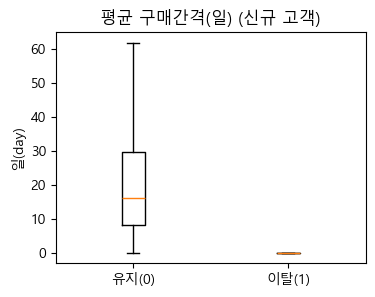

In [9]:
# 고객별 평균 구매간격 만들기
gap_mean = df.groupby('고객ID')['구매간격(일)'].mean().reset_index()
gap_mean.columns = ['고객ID', '평균구매간격']

cust_gap = customer_df[['고객ID','전체고객이탈여부']].merge(gap_mean, on='고객ID', how='left')
new_cust_gap = customer_df[['고객ID','신규고객이탈']].merge(gap_mean, on='고객ID', how='left')

keep = cust_gap[cust_gap['전체고객이탈여부']==0]['평균구매간격'].dropna()
churn = cust_gap[cust_gap['전체고객이탈여부']==1]['평균구매간격'].dropna()

keep_new = new_cust_gap[new_cust_gap['신규고객이탈']==0]['평균구매간격'].dropna()
churn_new = new_cust_gap[new_cust_gap['신규고객이탈']==1]['평균구매간격'].dropna()


plt.figure(figsize=(4,3))
plt.boxplot([keep, churn], labels=['유지(0)','이탈(1)'], showfliers=False)
plt.title('평균 구매간격(일)')
plt.ylabel('일(day)')
plt.tight_layout()


plt.figure(figsize=(4,3))
plt.boxplot([keep_new, churn_new], labels=['유지(0)','이탈(1)'], showfliers=False)
plt.title('평균 구매간격(일) (신규 고객)')
plt.ylabel('일(day)')
plt.show()

In [10]:
new_visualization_df = pd.read_csv('../../data/processed/final_EDA_df.csv')
new_visualization_df.head()

,고객ID,패션뉴스구독여부,멤버십상태,뉴스레터수신빈도,연령,구매일,가격,상품그룹,연령대,거래날짜,이전구매일,구매간격(일),API ratio,전체고객이탈여부,신규고객이탈
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.044051,Garment Upper body,40대,2018-12-27,0,0.0,68.666667,0,0
1,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.035576,Garment Upper body,40대,2018-12-27,2018-12-27 00:00:00,0.0,68.666667,0,0
2,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2018-12-27,0.030492,Garment Upper body,40대,2018-12-27,2018-12-27 00:00:00,0.0,68.666667,0,0
3,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-02,0.010153,Garment Full body,40대,2019-05-02,2018-12-27 00:00:00,126.0,68.666667,0,0
4,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0.0,ACTIVE,NONE,49.0,2019-05-25,0.050831,Garment Upper body,40대,2019-05-25,2019-05-02 00:00:00,23.0,68.666667,0,0


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def make_gradient_colors(s, cmap_name='Reds', min_level=0.35, max_level=0.95):
    vals = s.values.astype(float)
    vmin, vmax = vals.min(), vals.max()

    cmap = plt.get_cmap(cmap_name)

    # 값이 전부 같으면 중간 진하기로 통일
    if vmin == vmax:
        return [cmap((min_level + max_level) / 2)] * len(s)

    # 0~1 정규화
    norm = (vals - vmin) / (vmax - vmin)

    # ✅ 너무 연한 구간을 피해서 (min_level~max_level)만 사용
    norm = min_level + (max_level - min_level) * norm

    colors = [cmap(x) for x in norm]

    # (혹시라도 투명도 걱정되면 alpha=1로 고정)
    colors = [(*c[:3], 1.0) for c in colors]

    return colors

In [12]:
# # 대표 상품 그룹별 전체 이탈 여부
# # 이걸로 해야징

# rate_table = cust_prod.groupby('상품그룹')['전체고객이탈여부'].mean().sort_values(ascending=False)
# new_table = cust_prod.groupby('상품그룹')['신규고객이탈'].mean().sort_values(ascending=False)

# rate_table = rate_table.iloc[1:]
# new_table  = new_table.iloc[1:]

# all_top15 = rate_table.head(10)
# new_top15 = new_table.head(10)

# s1 = all_top15.sort_values()
# s2 = new_top15.sort_values()

# colors1 = make_gradient_colors(s1, 'Reds')
# colors2 = make_gradient_colors(s2, 'Greens')

# plt.subplot(1, 2, 1)
# ax = all_top15.sort_values().plot(kind='barh', figsize=(9,5), color= colors1)
# ax.set_title('대표 상품그룹별 전체 고객 이탈률 TOP10')
# ax.set_xlabel('이탈률')
# ax.bar_label(ax.containers[0],fmt='%.3f',padding=3)
# ax.set_xlim(0, s2.max() * 1.75)
# plt.tight_layout() # tight_layout()는 그래프 요소들이 겹치지 않도록 자동으로 조정하는 함수입니다.

# # 그래프 색상 설정

# plt.subplot(1, 2, 2)
# ax = new_top15.sort_values().plot(kind='barh', figsize=(9,5),color= colors2)
# ax.set_title("대표 상품그룹별 신규 고객 이탈률 TOP10")
# ax.set_xlabel('이탈률')
# ax.bar_label(ax.containers[0],fmt='%.3f',padding=3)
# ax.set_xlim(0, s2.max() * 1.4)

# plt.tight_layout()

# plt.show()